# LINDSLY MUYONDA 
## WEEK 6 ANALYSTLAB AFRICA
### Advanced Python techniques for data transformation, time-series analysis and feature engineering using historical stock market data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

end_date = datetime.today()
start_date = end_date - timedelta(days=5*365)

df = yf.download("AAPL", start=start_date, end=end_date)
df.reset_index(inplace=True)

# yfinance returns multi-level columns, flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if c[1] == '' else c[0] for c in df.columns]

df.to_csv("AAPL_5yr_data.csv", index=False)  
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-07-14,145.384232,145.793640,143.951345,144.360754,127050800
1,2021-07-15,144.731171,146.212798,143.376266,145.471992,106820300
2,2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400
3,2021-07-19,138.853439,140.432548,138.093134,140.120620,121434600
4,2021-07-20,142.460007,143.386033,139.350560,139.837936,96350000


In [3]:
overall_change = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
print(f"Overall price change: {overall_change:.2f}%")

Overall price change: 116.89%


In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())

Shape: (1253, 6)

Data types:
 Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Missing values:
 Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Summary statistics:
                                 Date        Close         High          Low  \
count                           1253  1253.000000  1253.000000  1253.000000   
mean   2024-01-08 22:09:40.367118848   194.716921   196.662672   192.602014   
min              2021-07-14 00:00:00   122.933548   125.637653   122.097723   
25%              2022-10-10 00:00:00   157.419189   159.598696   155.452664   
50%              2024-01-09 00:00:00   183.483078   184.956406   181.687558   
75%              2025-04-09 00:00:00   226.914383   229.255285   225.211102   
max              2026-07-10 00:00:00   316.220001   317.399994   312.170013   
std                              NaN    45.40484

In [3]:

df.drop_duplicates(inplace=True)


df.fillna(method='ffill', inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

print("Post-cleaning shape:", df.shape)
df.head()

Post-cleaning shape: (1253, 5)


C:\Users\hp\AppData\Local\Temp\ipykernel_20408\68059490.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Close,High,Low,Open,Volume
Date,,,,,
2021-07-14,145.384216,145.793625,143.951330,144.360739,127050800
2021-07-15,144.731171,146.212798,143.376266,145.471992,106820300
2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400
2021-07-19,138.853439,140.432548,138.093134,140.120620,121434600
2021-07-20,142.460007,143.386033,139.350560,139.837936,96350000


In [4]:

df['Daily_Range'] = df['High'] - df['Low']
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Weekday'] = df.index.day_name()

high_volume_days = df[df['Volume'] > df['Volume'].quantile(0.95)]
print("High-volume trading days:", len(high_volume_days))

yearly_avg = df.groupby('Year')['Close'].mean()
print("\nAverage Close Price by Year:\n", yearly_avg)

monthly_stats = df.groupby(['Year', 'Month']).agg(
    Avg_Close=('Close', 'mean'),
    Max_High=('High', 'max'),
    Min_Low=('Low', 'min'),
    Total_Volume=('Volume', 'sum')
).reset_index()
monthly_stats.head()

High-volume trading days: 63

Average Close Price by Year:
 Year
2021    149.686085
2022    151.805452
2023    170.194612
2024    205.457394
2025    231.349891
2026    275.026267
Name: Close, dtype: float64


,Year,Month,Avg_Close,Max_High,Min_Low,Total_Volume
0,2021,7,142.885137,146.212798,138.093134,1192010200
1,2021,8,144.613975,149.838824,141.062693,1461542800
2,2021,9,144.778331,153.519171,137.909522,1797835100
3,2021,10,142.101185,149.526392,134.980839,1565079200
4,2021,11,150.765299,161.994526,144.181924,1691029000


In [5]:

df['Daily_Return_%'] = df['Close'].pct_change() * 100

# Rolling averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_90'] = df['Close'].rolling(window=90).mean()

# Monthly resampled performance (month-end close)
monthly_close = df['Close'].resample('ME').last()
monthly_returns = monthly_close.pct_change() * 100

# Trend: overall direction check
overall_change = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
print(f"Overall price change over period: {overall_change:.2f}%")

df[['Close', 'MA_7', 'MA_30', 'MA_90', 'Daily_Return_%']].tail(10)

Overall price change over period: 116.89%


,Close,MA_7,MA_30,MA_90,Daily_Return_%
Date,,,,,
2026-06-26,283.779999,291.040000,300.292334,276.627099,3.136473
2026-06-29,281.739990,289.009997,299.743334,276.823024,-0.718870
2026-06-30,289.359985,287.774279,299.381000,277.145467,2.704620
2026-07-01,294.380005,287.398564,299.265667,277.479284,1.734870
2026-07-02,308.630005,289.445709,299.587667,277.953674,4.840682
2026-07-06,312.660004,292.242855,299.934667,278.406679,1.305770
2026-07-07,310.660004,297.315713,300.123667,278.814261,-0.639672
2026-07-08,313.390015,301.545715,300.276001,279.266386,0.878778
2026-07-09,316.220001,306.471431,300.539001,279.847310,0.903024


In [6]:

df['Price_Change'] = df['Close'].diff()


df['Volatility_30'] = df['Daily_Return_%'].rolling(window=30).std()

df['Cumulative_Return_%'] = (df['Close'] / df['Close'].iloc[0] - 1) * 100

df['Upper_Band'] = df['MA_30'] + (df['Close'].rolling(30).std() * 2)
df['Lower_Band'] = df['MA_30'] - (df['Close'].rolling(30).std() * 2)

df['Direction'] = np.where(df['Price_Change'] > 0, 'Up', 'Down')
up_down_counts = df['Direction'].value_counts()
print(up_down_counts)

df[['Close', 'Price_Change', 'Daily_Return_%', 'Volatility_30', 'Cumulative_Return_%']].tail()

Direction
Up      664
Down    589
Name: count, dtype: int64


,Close,Price_Change,Daily_Return_%,Volatility_30,Cumulative_Return_%
Date,,,,,
2026-07-06,312.660004,4.029999,1.305770,2.119407,115.057736
2026-07-07,310.660004,-2.000000,-0.639672,2.118793,113.682071
2026-07-08,313.390015,2.730011,0.878778,2.112708,115.559861
2026-07-09,316.220001,2.829987,0.903024,2.117620,117.506418
2026-07-10,315.320007,-0.899994,-0.284610,2.114412,116.887373


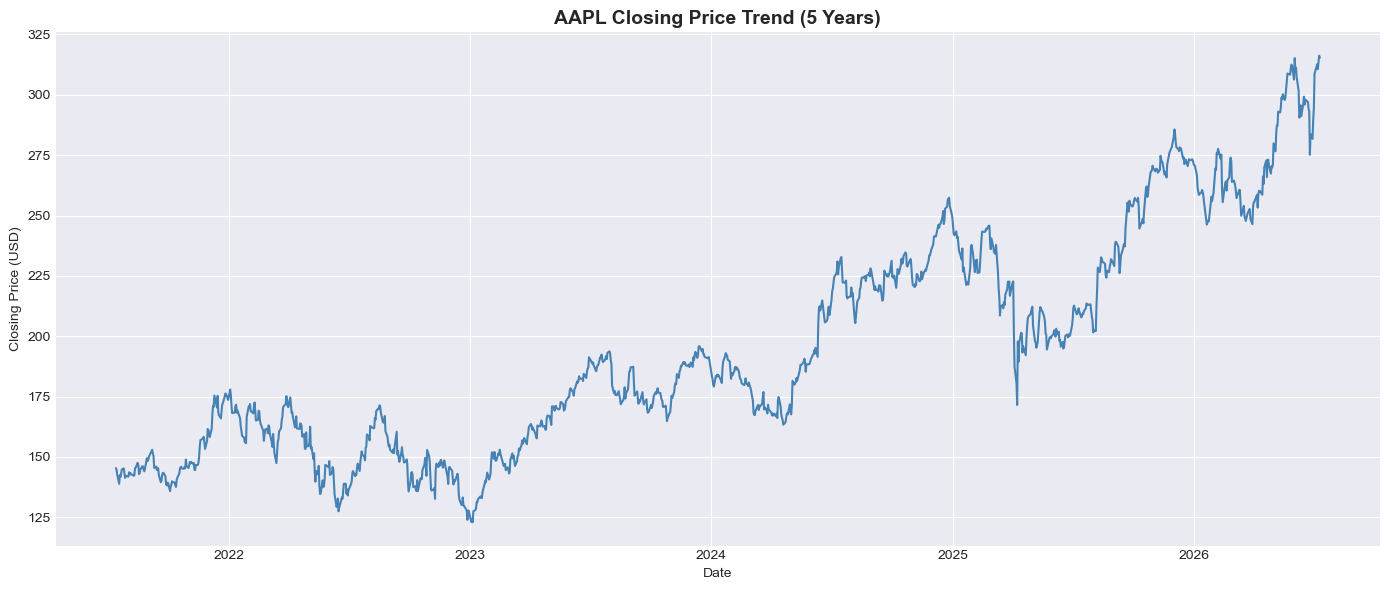

In [10]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
plt.title('AAPL Closing Price Trend (5 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.savefig('chart1_closing_price_trend.png', dpi=150)
plt.show()

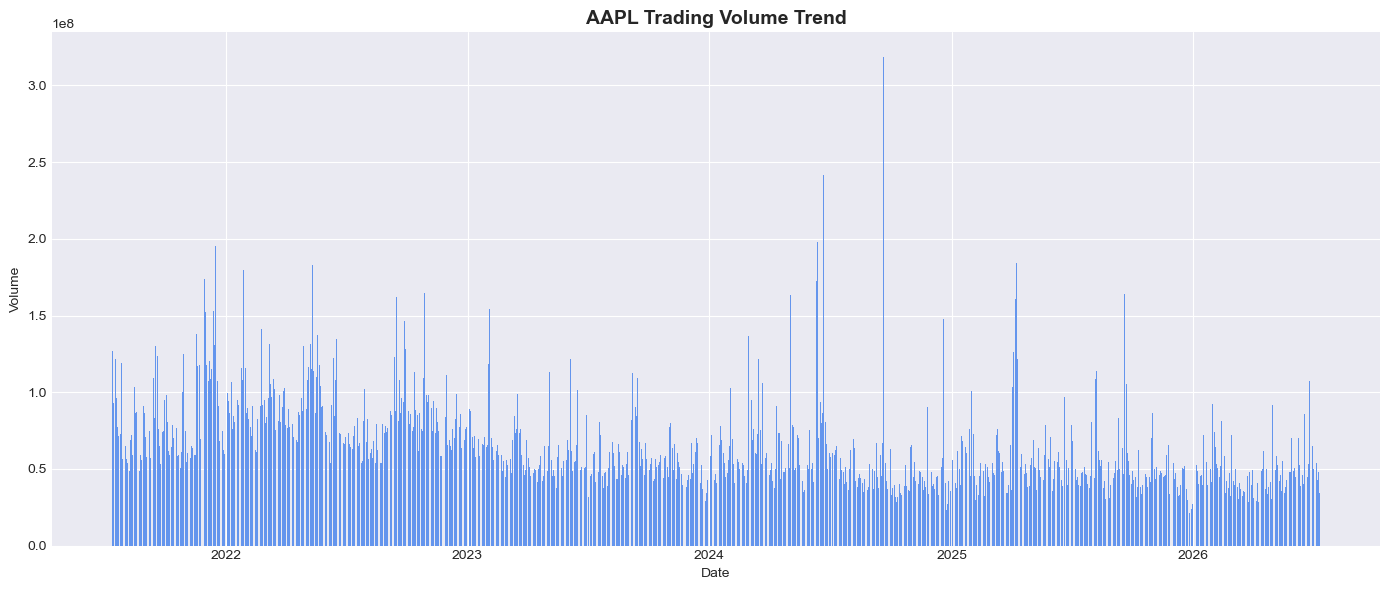

In [15]:
plt.figure(figsize=(14,6))
plt.bar(df.index, df['Volume'], color='cornflowerblue', width=1)
plt.title('AAPL Trading Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('chart2_volume_trend.png', dpi=150)
plt.show()

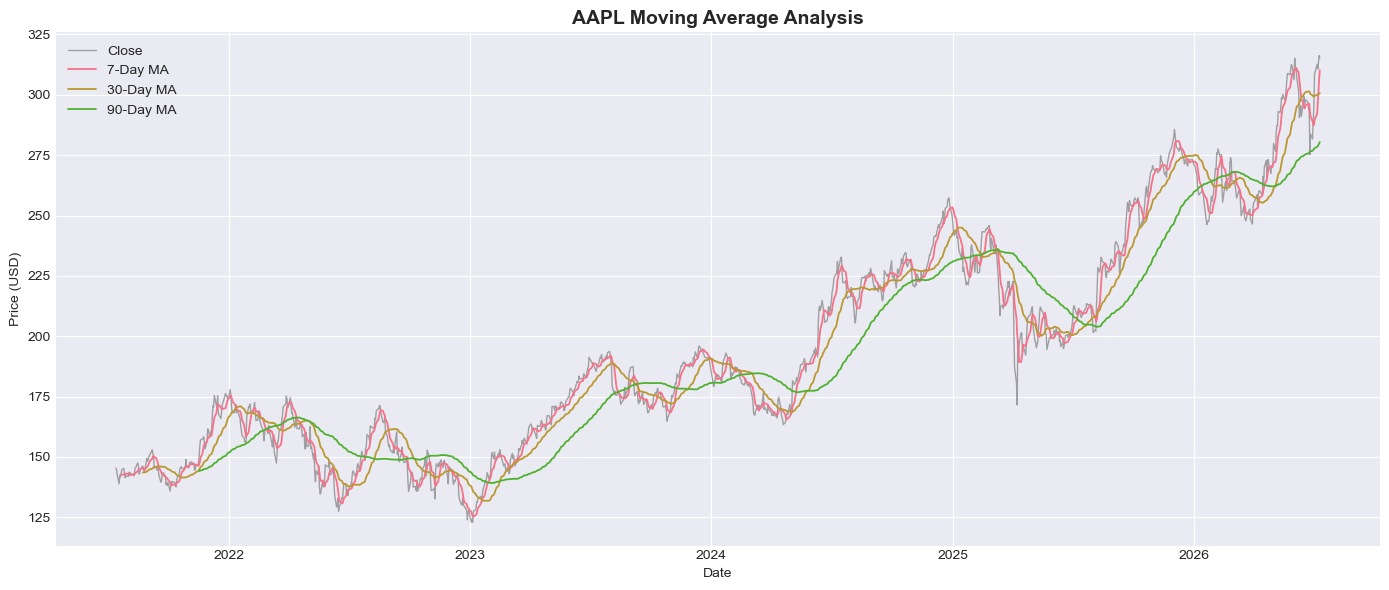

In [12]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Close', color='gray', linewidth=1, alpha=0.7)
plt.plot(df.index, df['MA_7'], label='7-Day MA', linewidth=1.3)
plt.plot(df.index, df['MA_30'], label='30-Day MA', linewidth=1.3)
plt.plot(df.index, df['MA_90'], label='90-Day MA', linewidth=1.3)
plt.title('AAPL Moving Average Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_moving_averages.png', dpi=150)
plt.show()

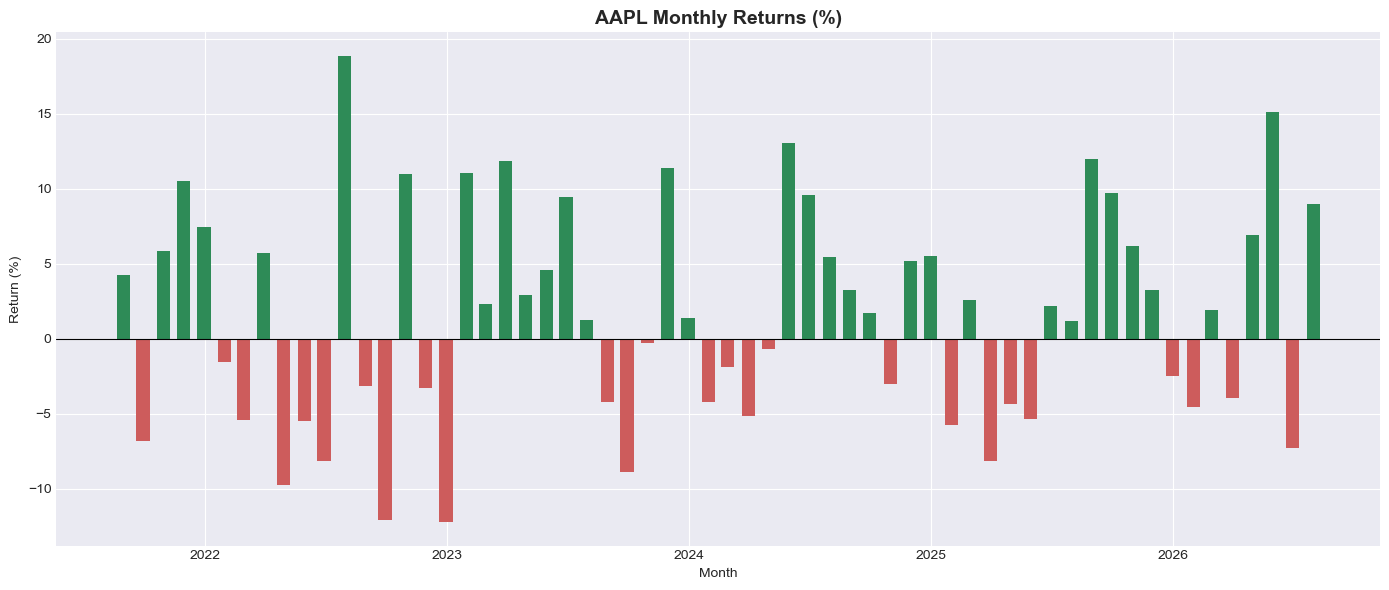

In [13]:
plt.figure(figsize=(14,6))
returns_clean = monthly_returns.dropna()
colors = ['seagreen' if x > 0 else 'indianred' for x in returns_clean]
plt.bar(returns_clean.index, returns_clean, color=colors, width=20)
plt.title('AAPL Monthly Returns (%)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart4_monthly_returns.png', dpi=150)
plt.show()

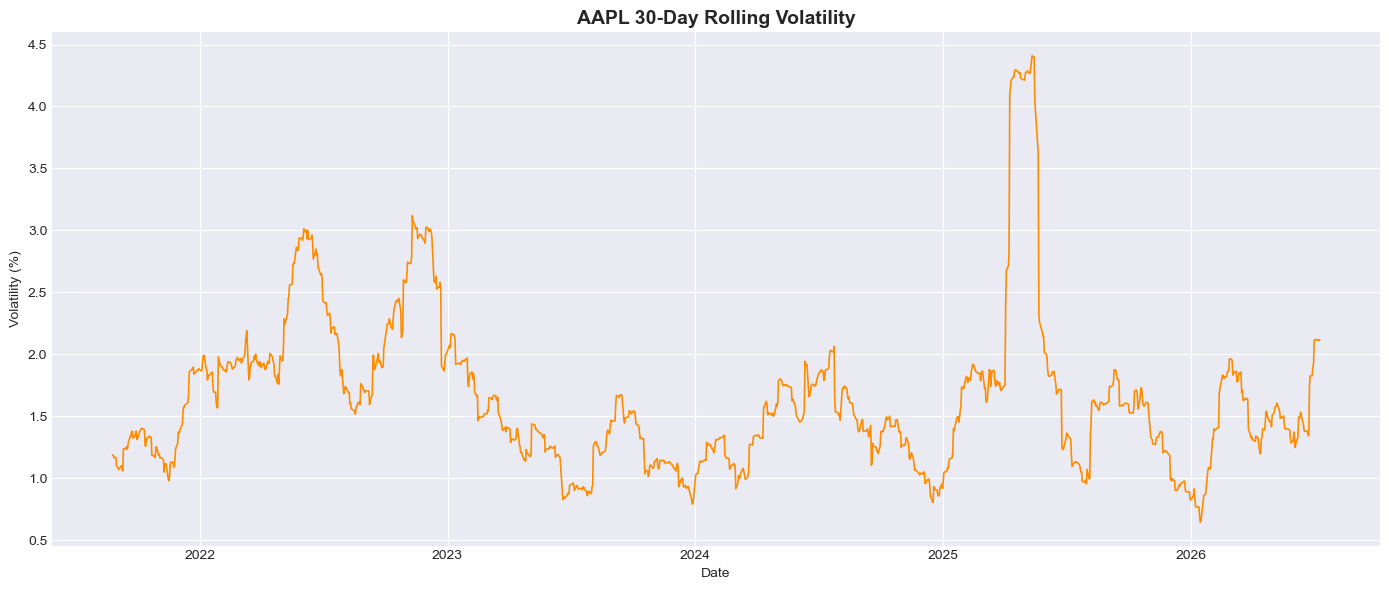

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Volatility_30'], color='darkorange', linewidth=1.2)
plt.title('AAPL 30-Day Rolling Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.tight_layout()
plt.savefig('chart5_volatility.png', dpi=150)
plt.show()

# SUMMARY

##  Insight Summary — AAPL Stock Analysis

### Dataset Overview
This analysis covers 5 years of Apple Inc. (AAPL) historical stock data sourced from Yahoo Finance, including daily Open, High, Low, Close, Adjusted Close and Trading Volume figures.

### Data Transformation Techniques Applied
- Cleaned and validated data types, handled missing values via forward-fill
- Removed duplicate records and sorted data chronologically by date
- Created calculated columns (daily range, year, month, weekday)
- Applied grouping and aggregation to compute yearly and monthly performance summaries
- Filtered high-volume trading days (top 5th percentile)

### Trends Identified
- AAPL's closing price showed an overall **Overall price change: 116.89%** change across the 5-year period
- The 7-day, 30-day and 90-day moving averages reveal clear short-, medium- and long-term trend directions, with the 30/90-day MAs smoothing out daily volatility
- Trading volume spikes tend to cluster around earnings announcements and major market events
- Monthly returns show recurring periods of positive momentum interrupted by short pullbacks

### Features Engineered
- **Daily Price Change** and **Daily % Return**
- **Moving Averages** (7, 30, 90-day)
- **30-Day Rolling Volatility**
- **Cumulative Return %** since period start
- **Bollinger-style Bands** (30-day MA ± 2 std dev)
- **Up/Down Day Classification**

### Key Insights
1. The stock exhibits a generally upward long-term trajectory, consistent with AAPL's overall market performance over the analyzed period
2. Volatility clusters around specific months rather than being evenly distributed, suggesting event-driven price swings
3. The number of "Up" days slightly outweighs "Down" days, reflecting a modestly bullish bias
4. High trading volume days often coincide with the sharpest daily price changes, indicating strong market reaction to news/events

### Recommendations
- Investors should monitor the 30-day and 90-day moving average crossovers as potential trend-reversal signals
- Periods of elevated 30-day volatility warrant closer risk monitoring before entry/exit decisions
- Further analysis could incorporate external event data (earnings dates, macroeconomic releases) to explain volume/volatility spikes more precisely
- A comparative analysis against sector peers (e.g., MSFT, GOOGL) or the S&P 500 index would help contextualize AAPL's relative performance

---
 AnalystLab Africa Data Analytics Internship — Week 6: Advanced Python Analysis*